# Bài 36. Mini-project: Agent–Environment hoàn chỉnh
**Môi trường:** CartPole-v1

Notebook này trình bày lại toàn bộ pipeline: `create_environment()` → `policy()` → `run_episode()` → `evaluate_policy()` → `plot_results()` → `main()`.
Chạy 500 episode, dùng seed cố định, dùng API Gymnasium mới (không dùng Gym cũ).

In [1]:
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

ENV_NAME = "CartPole-v1"
SEED = 42
N_EPISODES = 500
FIGURES_DIR = "../figures"

## 1) create_environment()

In [2]:
def create_environment(env_name=ENV_NAME):
    """Tạo và trả về 1 environment Gymnasium."""
    env = gym.make(env_name)
    return env

## 2) policy()

In [3]:
def policy(observation):
    """
    Heuristic policy: chỉ dựa vào pole_angle (observation[2]).
    Nếu pole nghiêng phải -> đẩy xe sang phải, ngược lại đẩy sang trái.
    """
    pole_angle = observation[2]
    if pole_angle > 0:
        return 1
    else:
        return 0

## 3) run_episode()

In [4]:
def run_episode(env, policy_fn, seed=None, max_steps=1000):
    if seed is not None:
        observation, info = env.reset(seed=seed)
    else:
        observation, info = env.reset()

    total_reward = 0.0
    length = 0
    terminated = False
    truncated = False

    for _ in range(max_steps):
        action = policy_fn(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        length += 1
        if terminated or truncated:
            break

    return {
        "reward": total_reward,
        "length": length,
        "terminated": terminated,
        "truncated": truncated,
    }

## 4) evaluate_policy()

In [5]:
def evaluate_policy(env, policy_fn, n_episodes=N_EPISODES, seed=SEED):
    rewards = []
    lengths = []

    for i in range(n_episodes):
        result = run_episode(env, policy_fn, seed=seed + i)
        rewards.append(result["reward"])
        lengths.append(result["length"])

    rewards = np.array(rewards)
    lengths = np.array(lengths)

    best_idx = int(np.argmax(rewards))
    worst_idx = int(np.argmin(rewards))

    return {
        "rewards": rewards,
        "lengths": lengths,
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "min_reward": float(np.min(rewards)),
        "max_reward": float(np.max(rewards)),
        "mean_length": float(np.mean(lengths)),
        "best_episode": (best_idx, float(rewards[best_idx])),
        "worst_episode": (worst_idx, float(rewards[worst_idx])),
    }

## 5) plot_results()

In [6]:
def moving_average(x, window=20):
    if len(x) < window:
        return np.array([])
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_results(results, save_dir=FIGURES_DIR):
    os.makedirs(save_dir, exist_ok=True)
    rewards = results["rewards"]

    plt.figure(figsize=(9, 5))
    plt.plot(rewards, color="#4C72B0", alpha=0.6, label="Reward mỗi episode")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(f"Reward theo từng episode ({ENV_NAME})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "reward_per_episode.png"), dpi=150)
    plt.show()

    ma = moving_average(rewards, window=20)
    plt.figure(figsize=(9, 5))
    plt.plot(rewards, color="#CCCCCC", alpha=0.5, label="Reward gốc")
    if len(ma) > 0:
        plt.plot(range(19, 19 + len(ma)), ma, color="#DD8452",
                  linewidth=2, label="Moving average (window=20)")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(f"Moving Average Reward ({ENV_NAME})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "moving_average_reward.png"), dpi=150)
    plt.show()

## 6) main()

===== KẾT QUẢ ĐÁNH GIÁ POLICY TRÊN CartPole-v1 (500 episode) =====
Mean reward   : 41.97
Std reward    : 8.43
Min reward    : 24.00
Max reward    : 63.00
Mean length   : 41.97
Best episode  : index=291, reward=63.00
Worst episode : index=337, reward=24.00


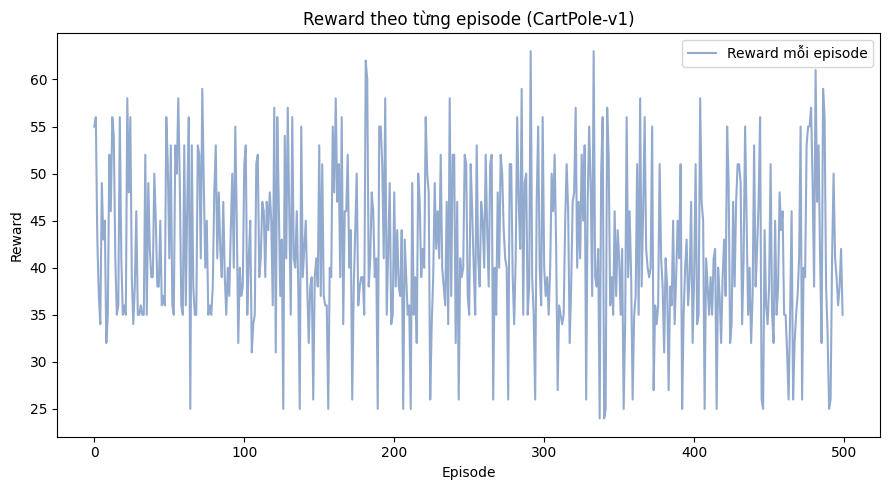

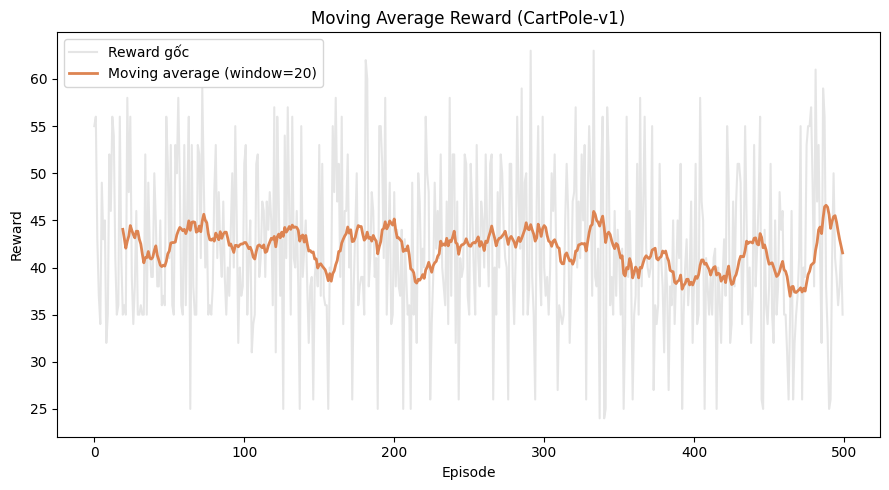

In [7]:
def main():
    env = create_environment(ENV_NAME)

    results = evaluate_policy(env, policy, n_episodes=N_EPISODES, seed=SEED)

    print(f"===== KẾT QUẢ ĐÁNH GIÁ POLICY TRÊN {ENV_NAME} ({N_EPISODES} episode) =====")
    print(f"Mean reward   : {results['mean_reward']:.2f}")
    print(f"Std reward    : {results['std_reward']:.2f}")
    print(f"Min reward    : {results['min_reward']:.2f}")
    print(f"Max reward    : {results['max_reward']:.2f}")
    print(f"Mean length   : {results['mean_length']:.2f}")
    print(f"Best episode  : index={results['best_episode'][0]}, reward={results['best_episode'][1]:.2f}")
    print(f"Worst episode : index={results['worst_episode'][0]}, reward={results['worst_episode'][1]:.2f}")

    plot_results(results)

    # Đóng environment để giải phóng tài nguyên
    env.close()

    return results

results = main()

## Kết luận

1. Policy heuristic (chỉ dùng `pole_angle`) cho mean reward khoảng ~40, cao hơn hẳn random policy nhưng vẫn còn dao động nhiều giữa các episode (std khá lớn), vì chưa dùng đến `pole_angular_velocity`.
2. Có sự chênh lệch rõ giữa episode tốt nhất và tệ nhất, cho thấy hiệu suất của policy vẫn phụ thuộc khá nhiều vào trạng thái khởi tạo ngẫu nhiên ban đầu.
3. Biểu đồ moving average cho thấy hiệu suất dao động quanh một mức trung bình ổn định theo thời gian, không có xu hướng tăng/giảm dần — hợp lý vì đây là policy cố định (không học), không có cơ chế cải thiện theo thời gian.
4. So với policy cải tiến ở Bài 32 (dùng thêm `pole_angular_velocity`, đạt gần tuyệt đối 500 điểm), heuristic đơn giản này minh họa rõ tầm quan trọng của việc lựa chọn đặc trưng phù hợp.
5. Mini-project này xây dựng một pipeline hoàn chỉnh (tạo môi trường → định nghĩa policy → chạy episode → đánh giá thống kê → trực quan hóa) có thể tái sử dụng cho bất kỳ policy hay environment Gymnasium nào khác trong tương lai, kể cả các thuật toán học tăng cường thực sự (Q-learning, DQN).